# More `matplotlib` & `pandas`

Today, we will cover more important `matplotlib` functions and get an introduction into the `pandas` library.

In [3]:
# preliminaries

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np

### Matplotlib

Let's make some fake data:

In [4]:
data = np.linspace(0, 10, 5)

And a nice plot to go along with it:

Text(0, 0.5, 'y-axis')

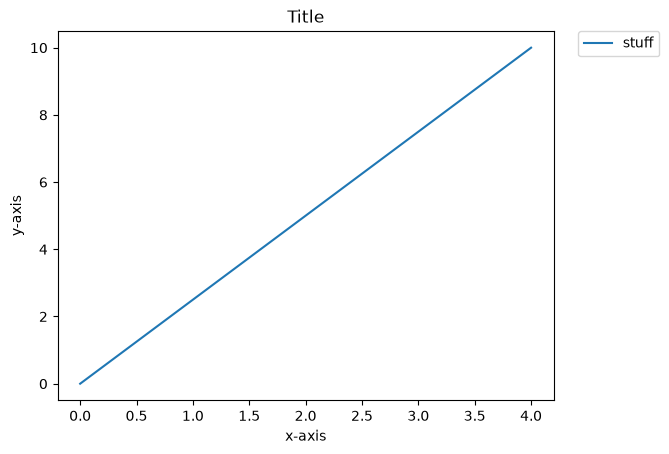

In [5]:
plt.plot(data,
        label = 'stuff')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Title')
plt.xlabel('x-axis')
plt.ylabel('y-axis')

### Matplotlib Figures

What `matplotlib` produces is a `Figure` object that is then printed off. To create and assign variable name to a `Figure` object, we can simply use `plt.figure`. This will create an empty figure that we can then manipulate.

In [7]:
fig = plt.figure()

<Figure size 432x288 with 0 Axes>

For example, we can add subplots (`AxesSubplot` objects):

In [8]:
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1,2)

One feature of Jupyter notebooks is that plots reset after each cell. This means you must put all the necessary lines for visualizing a given plot into one cell. For example, if I tried to plot `ax1` and `ax2` right now, I wouldn't visualize anything:

In [9]:
ax1.scatter([0,2],[3,4])
ax2.plot([1,2],[4,4])

If I instead include <i>all</i> necessary lines for plotting into one cell, I get what I want:

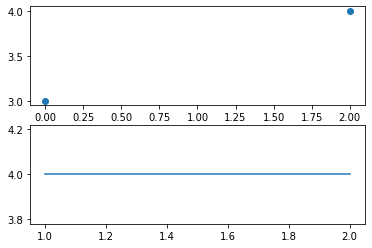

In [10]:
fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1,2)
ax1.scatter([0,2],[3,4])
ax2.plot([1,2],[4,4])

Note: In `fig.add_subplot(a, b, c)`, `a` is the number of rows, `b` is the number of columns and `c` is the current subplots order in the list. For example, I can swap the order of the two plots above and plot them side by side:

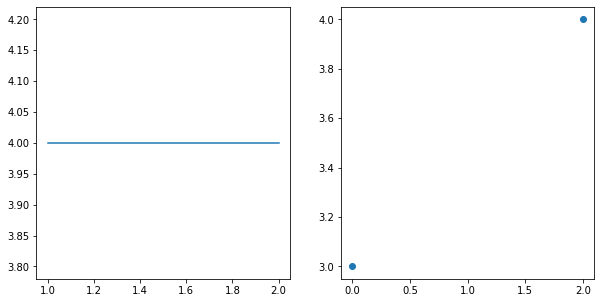

In [14]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(1, 2, 2) # switched to 1 row, 2 columns, and 2nd in line
ax2 = fig.add_subplot(1, 2, 1) # switched to 1 row, 2 columns, and 1st in line
ax1.scatter([0,2],[3,4])
ax2.plot([1,2],[4,4])

You can also use the `plt.subplots(row_count, column_count)` function to generate a numpy array of subplots:

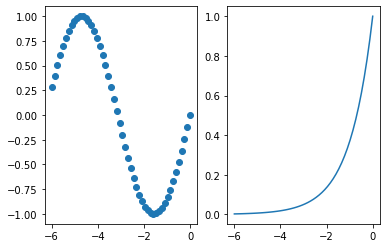

In [15]:
fig, axes = plt.subplots(1,2)
x = np.linspace(-6,0,50)

axes[0].scatter(x, np.sin(x))
axes[1].plot(x,np.exp(x))

There are lots of ways to tweak your plots. I will refer you to the full list to not bore you: [click here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). But, here are is a little laundry list you may go through if you like:

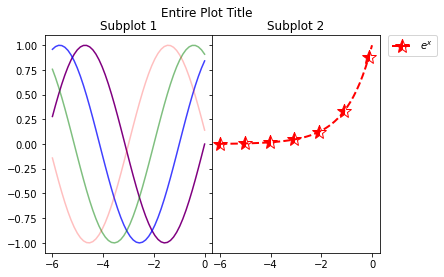

In [16]:
fig, axes = plt.subplots(1,2,
                        sharex = True, # share xticks
                        sharey = True) # share yticks

axes[0].set_title('Subplot 1') # subplot title
axes[1].set_title('Subplot 2') # subplot title
fig.suptitle('Entire Plot Title') # full plot title
fig.subplots_adjust(wspace=0, hspace=0) # space adjustment between subplots


x = np.linspace(-6,0,50)
axes[0].plot(x, np.sin(x), 
             color = 'purple', # color of line 
             alpha = 1) # opacity (0 is see through 1 is full color)
axes[0].plot(x, np.sin(x+1), 
             color = 'blue', 
             alpha=.75)
axes[0].plot(x, np.sin(x+2), 
             color = 'green', 
             alpha=.5)
axes[0].plot(x, np.sin(x+3), 
             color = 'red', 
             alpha=.25)

axes[1].plot(x, np.exp(x), 
             linestyle = "--", # line look
             color = 'red',
            linewidth = 2, # width
            fillstyle = 'left', # location of fill in point markers
            marker='*', # marker shapes
            markersize=15,
            markevery=8,  # skipping marking every so often
            label=r'$e^x$')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)



### Pandas
Pandas is a powerful data tool in Python we will discuss this week. First, Pandas is most useful as a file reader.

In [10]:
# name_you_want =  pd.read_csv("path_to_file") 
  
horsedata = pd.read_csv("https://raw.githubusercontent.com/garrett-kepler/Math-300----Mathematical-Computing/refs/heads/main/Datasets/Horses.csv") 

Note that this is reading from a link. You can also download the file and copy the path to that file on your device. 

Once the data is read, we can view it:

In [13]:
horsedata

,Horse,Race Finish Time
0,A,1230
1,B,1309
2,C,1279
3,D,1237
4,E,1328
5,F,1490
6,G,1243
7,H,1325
8,I,1428


While we read the file as a `.csv` file, Python will remember it as a `pd.DataFrame`:

In [14]:
type(horsedata)

pandas.DataFrame

We can visualize the data as well:

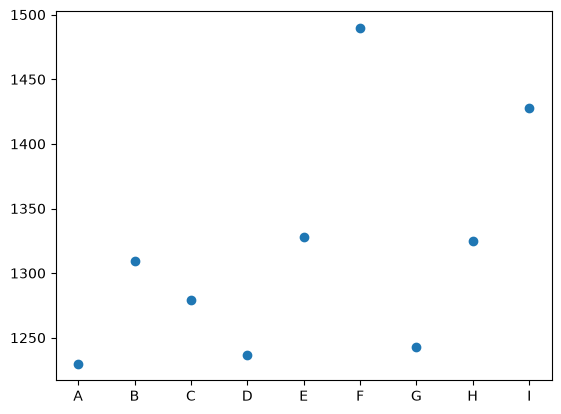

In [15]:
plt.scatter(horsedata['Horse'], horsedata['Race Finish Time'])

It's friendly relative `geopandas` is equally as useful for geometric data:

In [2]:
washcounties = gpd.read_file(r"C:\Users\Garrett\Downloads\WA_County_Boundaries\WA_County_Boundaries.shp")

In [3]:
washcounties

,OBJECTID,JURISDICT_,JURISDIC_1,JURISDIC_2,JURISDIC_3,JURISDIC_4,JURISDIC_5,JURISDIC_6,EDIT_DATE,EDIT_STATU,EDIT_WHO,GLOBALID,geometry
0,2229338,25,4,Grant,Grant County,13,53025,None,2018-03-15T00:26:49Z,1,TSTE490,{1DF7C3DA-B145-411F-9483-53BEFDA1C019},"POLYGON ((-13245041.204 6100462.041, -13245049..."
1,2231411,4698174,4,Pend Oreille,Pend Oreille County,26,53051,None,2025-11-20T00:40:36Z,0,TSTE490,{7D6E6B7F-1F96-444C-B6FE-F4E29312CA8C},"POLYGON ((-13028207.663 6215102.773, -13028213..."
2,2231418,4698173,4,Stevens,Stevens County,33,53065,None,2025-11-21T22:25:29Z,0,TSTE490,{AE9EAF1C-9552-4656-BC2B-948511BFD986},"POLYGON ((-13072259.109 6271668.868, -13072256..."
3,2233491,33,4,Garfield,Garfield County,12,53023,None,2022-06-23T23:47:50Z,1,TSTE490,{270AA9AE-163D-4CB1-9B9D-9D2D12AD60F9},"POLYGON ((-13077215.155 5893282.479, -13076922..."
4,2233852,8,4,Island,Island County,15,53029,None,2018-03-15T00:26:49Z,1,TSTE490,{ED2D90D3-E3E3-433A-8B6A-B061A1157FFD},"POLYGON ((-13645903.473 6175425.382, -13645833..."
5,2234461,20,4,Grays Harbor,Grays Harbor County,14,53027,None,2025-06-18T23:38:53Z,1,TSTE490,{6325153C-E0D2-4EA2-B20A-6F6E8005170C},"POLYGON ((-13818358.748 6029600.620, -13817157..."
6,2234462,4692894,4,Thurston,Thurston County,34,53067,None,2025-06-18T23:38:53Z,0,TSTE490,{93DFF6C6-3215-44BF-9AA6-70F3FA577C68},"POLYGON ((-13668140.191 5968532.266, -13667828..."
7,2234463,27,4,Lewis,Lewis County,21,53041,None,2025-06-18T23:38:53Z,1,TSTE490,{AB37FD9A-B8E6-4221-BBD8-A323F8F51C11},"POLYGON ((-13726667.316 5908398.973, -13724294..."
8,2234464,4,4,Skagit,Skagit County,29,53057,None,2024-12-05T00:36:04Z,1,TSTE490,{A2A98C7C-A90D-4F83-BF87-C9C157E3C367},"POLYGON ((-13646976.232 6211587.326, -13646829..."
9,2234465,4690632,4,Whatcom,Whatcom County,37,53073,None,2024-12-05T00:36:04Z,0,TSTE490,{3D96F9DB-5FE1-4993-B998-81BCE43E8F4B},"POLYGON ((-13661948.246 6275217.332, -13660730..."


Text(0.5, 1.0, 'Washington')

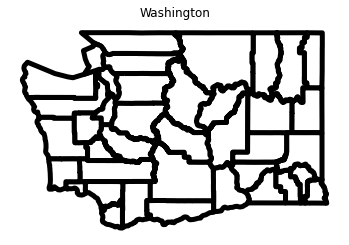

In [10]:
washcounties.plot(edgecolor='black', linewidth=5, facecolor='white')
plt.axis('off')
plt.title('Washington')


### Lab Problems

---


1.

Plot the function $f(x)=x^2$ for $x\in [-1,1]$ using `np.linspace()` with 10, 100, 1000 slices. Make sure your plot is as informative as possible.

---

2.

Pick a function $f(x)$ you like and plot some values using `plt.scatter()`. Make sure your plot is as informative as possible.

---

3.

Download the "Horses.xlsx" or "Horses.csv" file.
- Read the file in using `pandas`
- Plot the values using whatever plot type you like. Make sure your plot is as informative as possible.

---

4.

Download the "WA_County_Boundaries.shp" file. 
- Plot the state using `name_of_file_read.plot()`
- Plot some information about the state by extracting two columns of data.

### Lab Key*

---

1. 

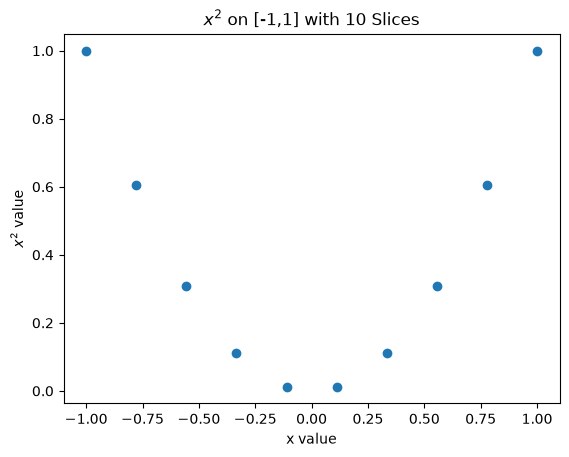

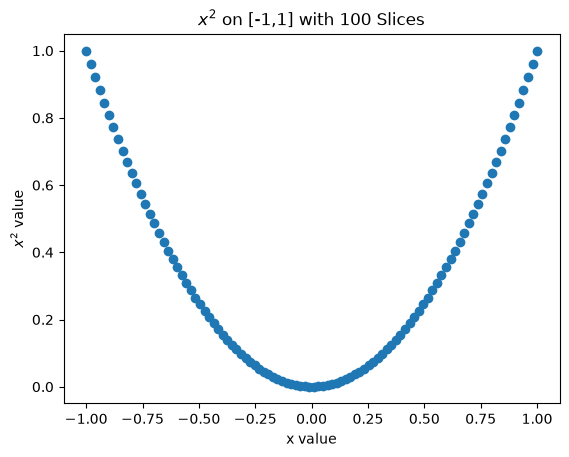

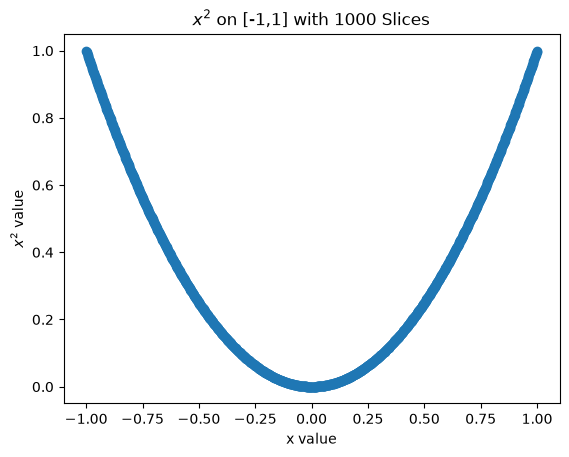

In [16]:
for i in [10,100,1000]:
    x = np.linspace(-1, 1, i)
    plt.title('$x^2$ on [-1,1] with '+str(i)+' Slices')
    plt.xlabel('x value')
    plt.ylabel('$x^2$ value')
    plt.scatter(x, x**2, 
                label=str(i)+' Slices')
    plt.show()

---

2. 

Text(0, 0.5, 'Function Value')

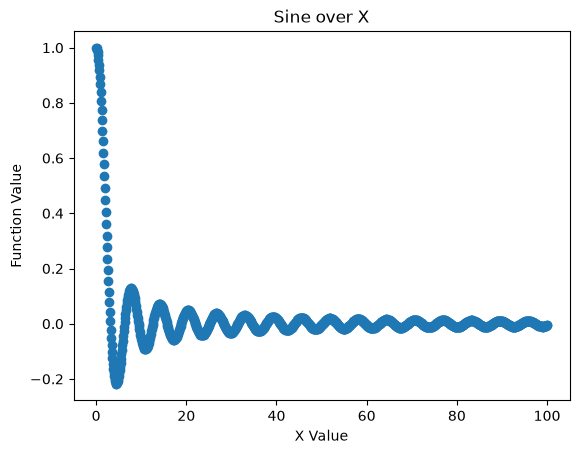

In [17]:
x = np.linspace(.01,100, 1000)
plt.scatter(x, np.sin(x)/x)
plt.title('Sine over X')
plt.xlabel('X Value')
plt.ylabel('Function Value')

---

3. 

Text(0.5, 1.0, 'Horse Racing Data')

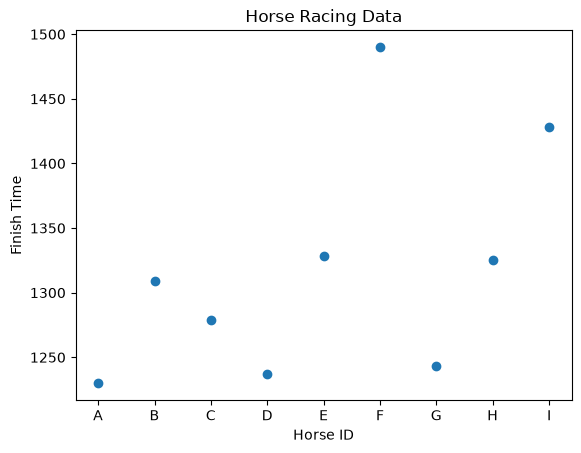

In [19]:
plt.scatter(horsedata['Horse'], horsedata['Race Finish Time'])
plt.xlabel('Horse ID')
plt.ylabel('Finish Time')
plt.title('Horse Racing Data')

---

4. 

In [ ]:
washington = gpd.read_file(r"path_on_your_device")

washington.plot('JURISDIC_4')
plt.title('Jurisdiction Identifier 4')
plt.axis('off')
plt.show()

washington.plot('JURISDIC_5')
plt.title('Jurisdiction Identifier 5')
plt.axis('off')